## Footstep eval: command XY → landing error

`log/footstep_eval_*.csv` (재빌드 후 스키마: `cmd_x,y,z,yaw` + `err_x,y,z,yaw`)를 읽어
stance-frame **command (x,y)** 위치에 **error 벡터 (err_x, err_y)** 를 quiver로 그립니다.

- 화살표: 명령 착지점 → 실제 착지점 (cmd − err = meas)
- 색: `|xy|` 오차 크기
- L/R은 marker로 구분

> 컨트롤러 재빌드·러닝 후 새 CSV가 필요합니다. 예전 스키마(z 없음)도 읽습니다.

2d_mys: files=5  steps=5000  |xy| mean=0.0577  std=0.0406  max=0.2994
2d_woik: files=5  steps=5000  |xy| mean=0.0537  std=0.0402  max=0.2473
2d_heuri2: files=5  steps=5000  |xy| mean=0.0370  std=0.0204  max=0.1383
2d_proposed: files=5  steps=5000  |xy| mean=0.0225  std=0.0125  max=0.0836
vmax 0.1505407559342613
vmax 0.1617209565198153
vmax 0.10407688579189635
vmax 0.05911066607725789
saved /home/yong/unitree_ws/g1_controller/log/exp1/exp1_plot.pdf


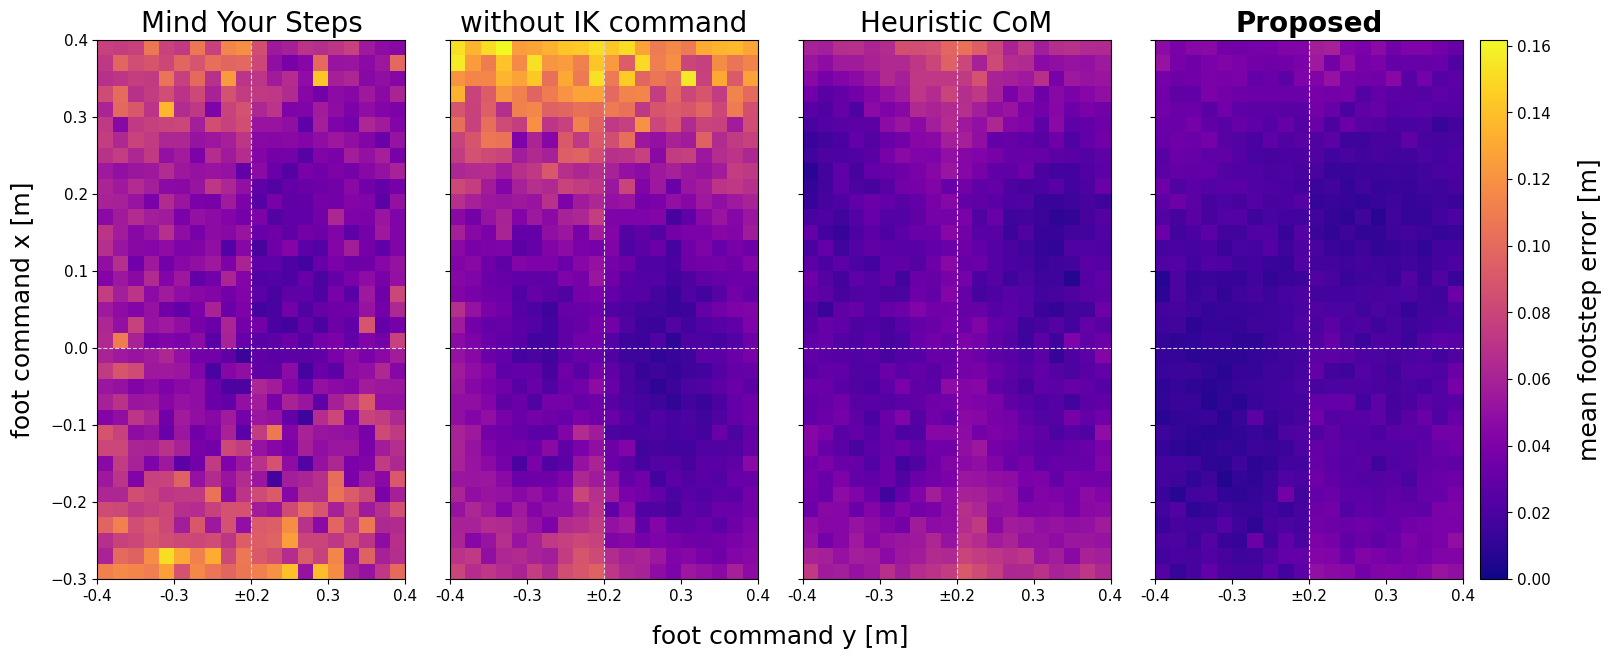

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# eval_dirs = [Path("2d_proposed"), Path("2d_woik"), Path("2d_heuri1"), Path("2d_heuri2"), Path("2d_mys")]
eval_dirs = [Path("2d_mys"), Path("2d_woik"), Path("2d_heuri2"), Path("2d_proposed")]


def load_eval_dir(log_dir: Path):
    cands = sorted(
        [p for p in log_dir.glob("*.csv")
         if not p.name.startswith("footstep_eval_mys")],
        key=lambda p: p.name,
    )
    assert cands, f"no csv found in {log_dir.resolve()}"
    frames = []
    for p in cands:
        df = pd.read_csv(p)
        df["run"] = p.stem
        frames.append(df)
    E = pd.concat(frames, ignore_index=True)
    for col in ("cmd_z", "meas_z", "err_z"):
        if col not in E.columns:
            E[col] = 0.0
    cmd_xy = E[["cmd_x", "cmd_y"]].to_numpy()
    err_xy = E[["err_x", "err_y"]].to_numpy()
    mag = np.hypot(err_xy[:, 0], err_xy[:, 1])
    print(f"{log_dir.name}: files={len(cands)}  steps={len(E)}  "
          f"|xy| mean={mag.mean():.4f}  std={mag.std():.4f}  max={mag.max():.4f}")
    return dict(E=E, cmd_xy=cmd_xy, err_xy=err_xy, mag=mag,
                err_z=E["err_z"].to_numpy(), err_yaw=E["err_yaw"].to_numpy(),
                foot=E["foot"].astype(str).to_numpy(),
                meas_xy=cmd_xy - err_xy, files=cands)


runs = {d.name: load_eval_dir(d) for d in eval_dirs}
# last dir kept as E / cmd_xy / mag so later scatter cells still run
last = runs[eval_dirs[-1].name]
E, cmd_xy, mag = last["E"], last["cmd_xy"], last["mag"]
err_xy, err_z, err_yaw = last["err_xy"], last["err_z"], last["err_yaw"]
foot, meas_xy = last["foot"], last["meas_xy"]
E.head()


# Heatmap of mean Euclidean XY error on command XY, one subplot per eval folder.
# Shared grid / color scale so 2d_proposed vs 2d_woik are comparable.
from matplotlib.ticker import FuncFormatter, MultipleLocator

y_gap = 0.2
tick = 0.1
bin_size = 0.02  # grid resolution; smaller → sharper, needs more samples
title_fs = 20    # subplot titles
label_fs = 18    # axis / colorbar labels
tick_fs = 11     # tick labels
cb_labelpad = 20 # gap between colorbar and its label
subplot_wspace = -0.4  # gap between heatmaps
ylabel_pad = 12        # gap between ylabel and first heatmap


def snap_lim(lo, hi, step=tick):
    return float(np.floor(lo / step) * step), float(np.ceil(hi / step) * step)


def cmd_to_plot(cmd_xy):
    cmd_y = cmd_xy[:, 1]
    cmd_x = cmd_xy[:, 0]
    y_plot = np.where(cmd_y >= 0, cmd_y - y_gap, cmd_y + y_gap)
    return y_plot, cmd_x


names = [d.name for d in eval_dirs]
titles = ["Mind Your Steps", "without IK command", "Heuristic CoM", "Proposed"]
y_all = np.concatenate([cmd_to_plot(runs[n]["cmd_xy"])[0] for n in names])
x_all = np.concatenate([cmd_to_plot(runs[n]["cmd_xy"])[1] for n in names])
x0, x1 = snap_lim(y_all.min(), y_all.max())
y0, y1 = snap_lim(x_all.min(), x_all.max())
xedges = np.arange(x0, x1 + bin_size * 0.5, bin_size)
yedges = np.arange(y0, y1 + bin_size * 0.5, bin_size)

heat = []
vmax = 1e-6
for n in names:
    y_plot, cmd_x = cmd_to_plot(runs[n]["cmd_xy"])
    mag = runs[n]["mag"]
    sum_e, _, _ = np.histogram2d(y_plot, cmd_x, bins=[xedges, yedges], weights=mag)
    cnt, _, _ = np.histogram2d(y_plot, cmd_x, bins=[xedges, yedges])
    with np.errstate(invalid="ignore", divide="ignore"):
        mean_e = sum_e / cnt
    mean_e = np.ma.masked_where(cnt == 0, mean_e)
    heat.append(mean_e)
    if np.ma.count(mean_e):
        vmax = max(vmax, float(np.nanmax(mean_e)))
        print("vmax", float(np.nanmax(mean_e)))

fig, axes = plt.subplots(
    1, len(names), figsize=(5.5 * len(names), 7), sharey=True,
    gridspec_kw={"wspace": subplot_wspace},
)
if len(names) == 1:
    axes = [axes]
pcm = None
for ax, n, mean_e, t in zip(axes, names, heat, titles):
    pcm = ax.pcolormesh(
        xedges, yedges, mean_e.T,
        cmap="plasma", shading="auto",
        # vmin=0.0, vmax=0.2,
        vmin=0.0, vmax=vmax,
        rasterized=True,
    )
    ax.axhline(0, color="0.85", lw=0.8, ls="--")
    ax.axvline(0, color="0.85", lw=0.8, ls="--")
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_aspect("equal", adjustable="box")
    ax.xaxis.set_major_locator(MultipleLocator(tick))
    ax.yaxis.set_major_locator(MultipleLocator(tick))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: "±0.2" if abs(v) < 1e-12 else f"{(v - y_gap) if v < 0 else (v + y_gap):.1f}"))
    ax.set_title(t, fontsize=title_fs, fontweight="bold" if t == "Proposed" else "normal")
    ax.tick_params(axis="both", labelsize=tick_fs)
    # if ax is not axes[0]:
        # ax.tick_params(axis="x", labelbottom=False)
    # ax.grid(True, which="major", color="w", alpha=0.25, lw=0.)
    ax.grid(False)
axes[0].set_ylabel("foot command x [m]", fontsize=label_fs, labelpad=ylabel_pad)
cb = fig.colorbar(pcm, ax=axes, fraction=0.025, pad=0.01)
cb.set_label("mean footstep error [m]", fontsize=label_fs, labelpad=cb_labelpad)
cb.ax.tick_params(labelsize=tick_fs)
fig.canvas.draw()
pos0 = axes[0].get_position()
pos1 = axes[-1].get_position()
fig.supxlabel(
    "foot command y [m]", fontsize=label_fs,
    x=0.5 * (pos0.x0 + pos1.x1),
)
# fig.tight_layout()
pdf_path = Path("exp1_plot.pdf")
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
fig.savefig("exp1_plot.png", format="png", bbox_inches="tight")
print(f"saved {pdf_path.resolve()}")
plt.show()


saved /home/yong/unitree_ws/g1_controller/log/exp1/exp1_plot_2x2.pdf


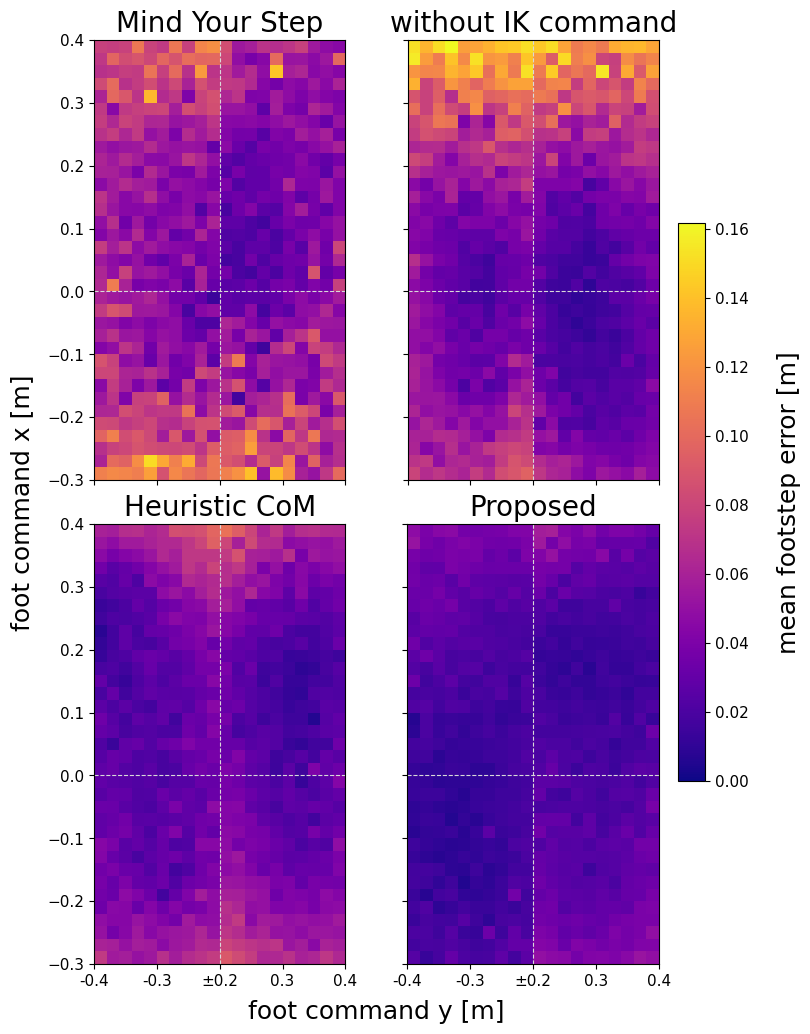

In [23]:
# 2x2 heatmap (same data / color scale as the 1xN plot above)
assert len(names) == 4, "2x2 layout expects 4 eval dirs"

subplot2_wspace = -0.45  # column gap; more negative → tighter
subplot2_hspace = 0.1  # row gap; more negative → tighter
ylabel2_xpad = 0.07      # figure-fraction gap from left heatmaps; smaller → closer
xlabel2_ypad = 0.05      # figure-fraction gap from bottom heatmaps; smaller → closer

fig2, axes2 = plt.subplots(
    2, 2, figsize=(12, 12), sharex=True, sharey=True,
    gridspec_kw={"wspace": subplot2_wspace, "hspace": subplot2_hspace},
)
pcm2 = None
for ax, mean_e, t in zip(axes2.ravel(), heat, titles):
    pcm2 = ax.pcolormesh(
        xedges, yedges, mean_e.T,
        cmap="plasma", shading="auto",
        vmin=0.0, vmax=vmax,
        rasterized=True,
    )
    ax.axhline(0, color="0.85", lw=0.8, ls="--")
    ax.axvline(0, color="0.85", lw=0.8, ls="--")
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_aspect("equal", adjustable="box")
    ax.xaxis.set_major_locator(MultipleLocator(tick))
    ax.yaxis.set_major_locator(MultipleLocator(tick))
    ax.xaxis.set_major_formatter(FuncFormatter(
        lambda v, _: "±0.2" if abs(v) < 1e-12
        else f"{(v - y_gap) if v < 0 else (v + y_gap):.1f}"
    ))
    ax.set_title(t, fontsize=title_fs, fontweight="bold" if t == "Proposed" else "normal")
    ax.tick_params(axis="both", labelsize=tick_fs)
    ax.grid(False)

cb2 = fig2.colorbar(pcm2, ax=axes2, fraction=0.03, pad=0.02)
cb2.set_label("mean footstep error [m]", fontsize=label_fs, labelpad=cb_labelpad)
cb2.ax.tick_params(labelsize=tick_fs)
fig2.canvas.draw()
pos_tl = axes2[0, 0].get_position()
pos_bl = axes2[1, 0].get_position()
pos_tr = axes2[0, 1].get_position()
fig2.supxlabel(
    "foot command y [m]", fontsize=label_fs,
    x=0.5 * (pos_tl.x0 + pos_tr.x1),
    y=pos_bl.y0 - xlabel2_ypad,
)
fig2.supylabel(
    "foot command x [m]", fontsize=label_fs,
    x=pos_tl.x0 - ylabel2_xpad,
    y=0.5 * (pos_bl.y0 + pos_tl.y1),
)
pdf_path_2x2 = Path("exp1_plot_2x2.pdf")
fig2.savefig(pdf_path_2x2, format="pdf", bbox_inches="tight")
fig2.savefig("exp1_plot_2x2.png", format="png", bbox_inches="tight")
print(f"saved {pdf_path_2x2.resolve()}")
plt.show()
